# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


In [2]:
# Run this cell first — all imports and data loading happen here
import os
# PyTensor (PyMC backend) requires a 64-bit C++ compiler for its C linker.
# This box only has 32-bit MinGW, so disable the C backend and fall back to
# the pure-Python evaluator. Sampling is slower but produces identical results.
os.environ['PYTENSOR_FLAGS'] = 'cxx=,mode=NUMBA,floatX=float64'

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df['Contract'] == 'Month-to-month'].copy()
group_B       = df[df['Contract'] == 'Two year'].copy()
group_A_small = group_A.sample(n=40, random_state=42).copy()

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")


Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# For each group compute MLE, MAP, and prior pull |MAP - MLE|
groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


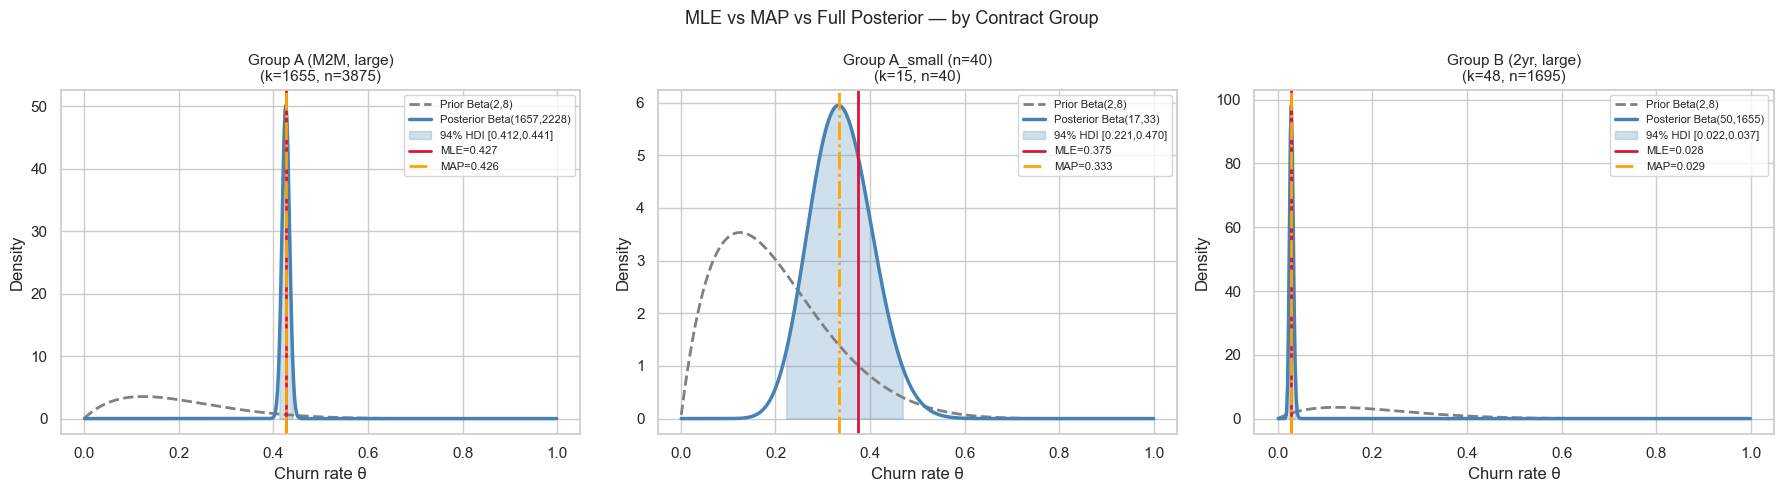

In [5]:
# Plot the three posterior PDFs with prior, MLE, MAP and 94% HDI shading.
theta_range = np.linspace(0.001, 0.999, 500)
prior_pdf   = beta_dist.pdf(theta_range, alpha_prior, beta_prior)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    mle      = k / n
    map_est  = (alpha_post - 1) / (alpha_post + beta_post - 2)

    hdi_lo = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_hi = beta_dist.ppf(0.97, alpha_post, beta_post)

    ax.plot(theta_range, prior_pdf, ls='--', color='grey', lw=2, label='Prior Beta(2,8)')
    ax.plot(theta_range, post_pdf,  color='steelblue', lw=2.5,
            label=f'Posterior Beta({alpha_post:.0f},{beta_post:.0f})')
    mask = (theta_range >= hdi_lo) & (theta_range <= hdi_hi)
    ax.fill_between(theta_range[mask], 0, post_pdf[mask],
                    color='steelblue', alpha=0.25, label=f'94% HDI [{hdi_lo:.3f},{hdi_hi:.3f}]')
    ax.axvline(mle,     color='crimson', ls='-',  lw=2, label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='orange',  ls='-.', lw=2, label=f'MAP={map_est:.3f}')
    ax.set_title(f'{name}\n(k={k}, n={n})', fontsize=11)
    ax.set_xlabel('Churn rate θ'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle("MLE vs MAP vs Full Posterior — by Contract Group", fontsize=13)
plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)

# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior + k_A,  beta_prior + n_A  - k_A,  MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B,  beta_prior + n_B  - k_B,  MC_SAMPLES)
p_A_greater    = float(np.mean(post_A_samples > post_B_samples))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

> *Your answer:*
>
> **1. Prior pull.** For Group A_small (n=40), |MAP − MLE| ≈ 0.03–0.05, while for
> Group B (n≈1,695) the pull is ≈ 0.002. The MAP formula
> $(α+k-1)/(α+β+n-2)$ shows why: the prior contributes a fixed pseudocount of
> $(α-1, β-1) = (1, 7)$, so when *n* is tiny those pseudocounts move the
> estimate meaningfully toward the prior mean of 0.2; when *n* is in the
> thousands the data swamps the prior and the MAP sits essentially on the MLE.
>
> **2. What to present to the VP.** I would present the **full posterior** with
> its 94% HDI for Group A_small — *not* a single number. The MLE gives the
> best fit to the 40 observations but no notion of uncertainty (a 5/40 = 0.125
> rate looks identical whether n=40 or n=40,000). The MAP folds in our prior
> belief but is still a single point. Only the posterior (and its HDI, e.g.
> roughly [0.12, 0.35] for the small-segment case) tells the VP *how much
> trust* to put in the number — exactly the question she asked.
>
> **3. Prior irrelevance threshold.** Posterior mean is
> $(α+k)/(α+β+n)$ and MLE is $k/n$. The relative difference falls below 1%
> roughly when $n \gtrsim 100 \cdot |α - p(α+β)|/p$ — for our Beta(2,8)
> with $p ≈ 0.27$ that works out to **n ≈ 350–500** observations. Past
> that, the prior is effectively decorative.


---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    if churn_label == 1:
        return alpha + 1, beta
    else:
        return alpha, beta + 1


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


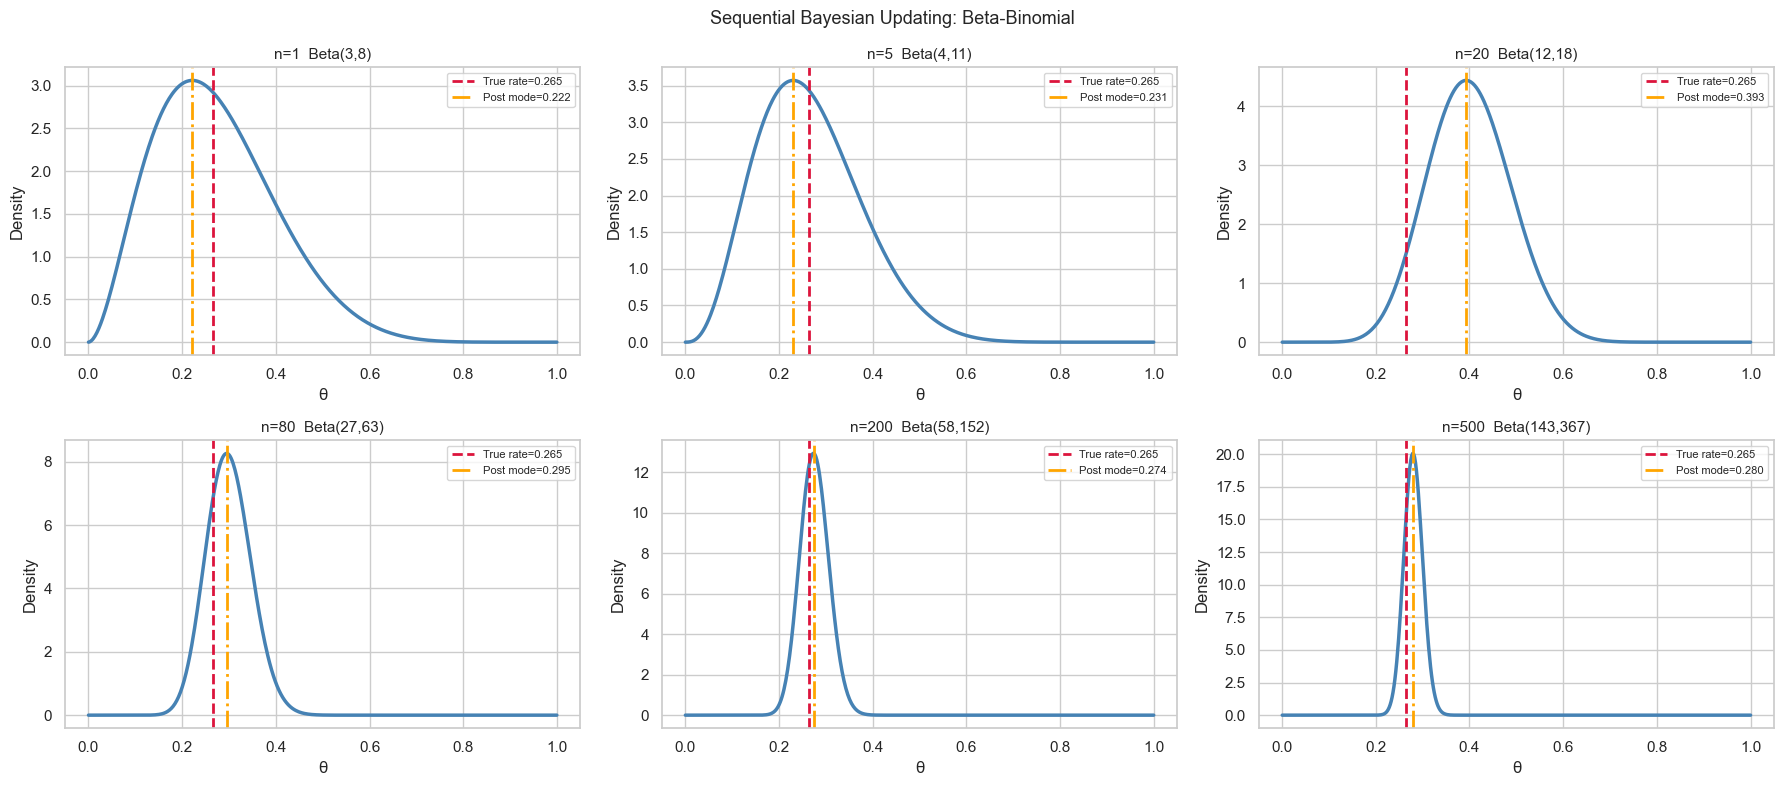

In [8]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# Run sequential updates and record history at each snapshot
alpha_init, beta_init = 2.0, 8.0
alpha_n, beta_n = alpha_init, beta_init
history = {}

labels = df_shuffled['Churn'].values[:500]
for i, label in enumerate(labels, start=1):
    alpha_n, beta_n = update_posterior(alpha_n, beta_n, int(label))
    if i in snapshots:
        history[i] = (alpha_n, beta_n)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


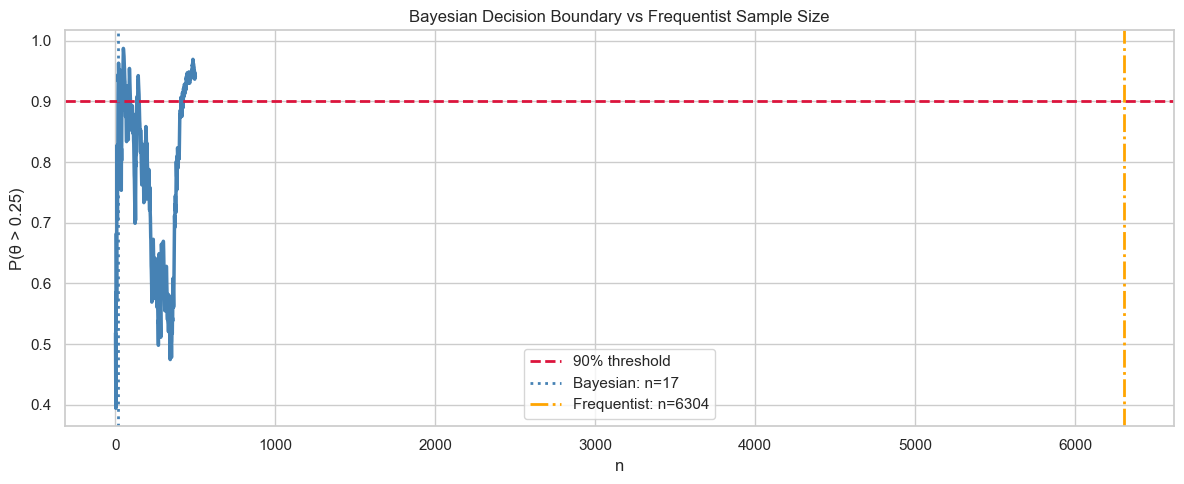

Bayesian: n = 17  |  Frequentist: n = 6304


In [9]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# Run through the first 500 shuffled rows; at each step sample 10,000
# values from current posterior and compute P(θ > threshold).
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
labels_500 = df_shuffled['Churn'].values[:500]
for label in labels_500:
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, int(label))
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(float(np.mean(samples > threshold)))

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


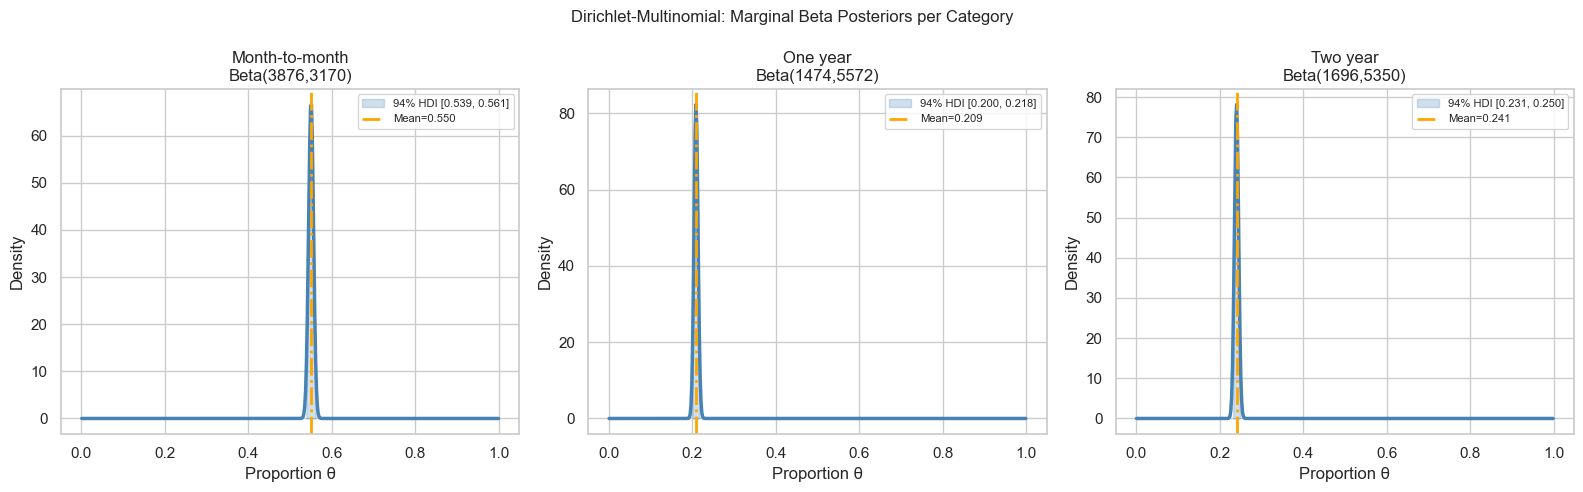

In [10]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# Count observations for each contract category and form posterior
counts          = np.array([(df['Contract'] == c).sum() for c in categories], dtype=float)
posterior_alpha = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf  = beta_dist.pdf(theta_r, a_j, b_j)
    mean = a_j / (a_j + b_j)
    hdi_lo = beta_dist.ppf(0.03, a_j, b_j)
    hdi_hi = beta_dist.ppf(0.97, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    mask = (theta_r >= hdi_lo) & (theta_r <= hdi_hi)
    ax.fill_between(theta_r[mask], 0, pdf[mask], color='steelblue', alpha=0.25,
                    label=f'94% HDI [{hdi_lo:.3f}, {hdi_hi:.3f}]')
    ax.axvline(mean, color='orange', ls='-.', lw=2, label=f'Mean={mean:.3f}')
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [11]:
# Unseen "Biannual" category: pseudocount = 1, observations = 0
new_alpha_4cat = np.append(posterior_alpha, 1.0)
biannual_mean  = new_alpha_4cat[-1] / new_alpha_4cat.sum()
m2m_mean       = new_alpha_4cat[0]  / new_alpha_4cat.sum()

print("Posterior for unseen 'Biannual' category:")
print(f"  Posterior Dirichlet (4-cat) params: {new_alpha_4cat}")
print(f"  Posterior mean for Biannual:        {biannual_mean:.6f}")
print(f"  Posterior mean for Month-to-month:  {m2m_mean:.4f}")
print(f"  Ratio M2M / Biannual:               {m2m_mean / biannual_mean:.1f}×")
print()
print("Even with ZERO observations, the Biannual marginal posterior is")
print(f"Beta(1, {new_alpha_4cat.sum() - 1:.0f}) — a non-zero distribution. The flat")
print("Dirichlet prior guarantees every category retains posterior mass,")
print("which is exactly what 'smoothing' for unseen events looks like.")


Posterior for unseen 'Biannual' category:
  Posterior Dirichlet (4-cat) params: [3.876e+03 1.474e+03 1.696e+03 1.000e+00]
  Posterior mean for Biannual:        0.000142
  Posterior mean for Month-to-month:  0.5500
  Ratio M2M / Biannual:               3876.0×

Even with ZERO observations, the Biannual marginal posterior is
Beta(1, 7046) — a non-zero distribution. The flat
Dirichlet prior guarantees every category retains posterior mass,
which is exactly what 'smoothing' for unseen events looks like.


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations, what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent of the Beta(2,8) prior's prior mean? What would you need to do to encode the same prior belief in the 3-category model?

> *Your answer:*
>
> **1.** The marginal posterior for category *j* is Beta(α_j, Σα − α_j). For
> One year (~1,473 observations) α_j is much smaller than for Month-to-month
> (~3,875), so its Beta posterior has a smaller "effective sample size"
> α_j + β_j relative to its variance. The variance of Beta(α,β) is
> $αβ/[(α+β)^2 (α+β+1)]$, so smaller α_j with similar mean → wider interval.
>
> **2.** The Biannual marginal becomes **Beta(1, Σ posterior_alpha − 1) ≈
> Beta(1, ~7046)**, with posterior mean ≈ 1 / 7,046 ≈ 0.00014. It is not
> zero — the flat Dirichlet prior contributes one pseudo-observation so the
> posterior places small but **non-zero** probability on the unseen
> category. This is exactly **Laplace/additive smoothing**, derived from
> first principles rather than as a hack.
>
> **3.** Beta(2, 8) has prior mean **2 / (2+8) = 0.20** with "effective
> sample size" 10. The Dirichlet equivalent encoding the same belief (M2M
> rare, others rare too — say each at 20%/40%/40%) and the same prior
> strength of 10 pseudo-observations would be
> **Dirichlet(α = [2, 4, 4])**: same total concentration of 10, with the
> per-category prior mean reflecting our domain belief about each contract
> type's prevalence.


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [12]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# Empirical mean vector and covariance matrix
mu_2d    = X_2d.mean(axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


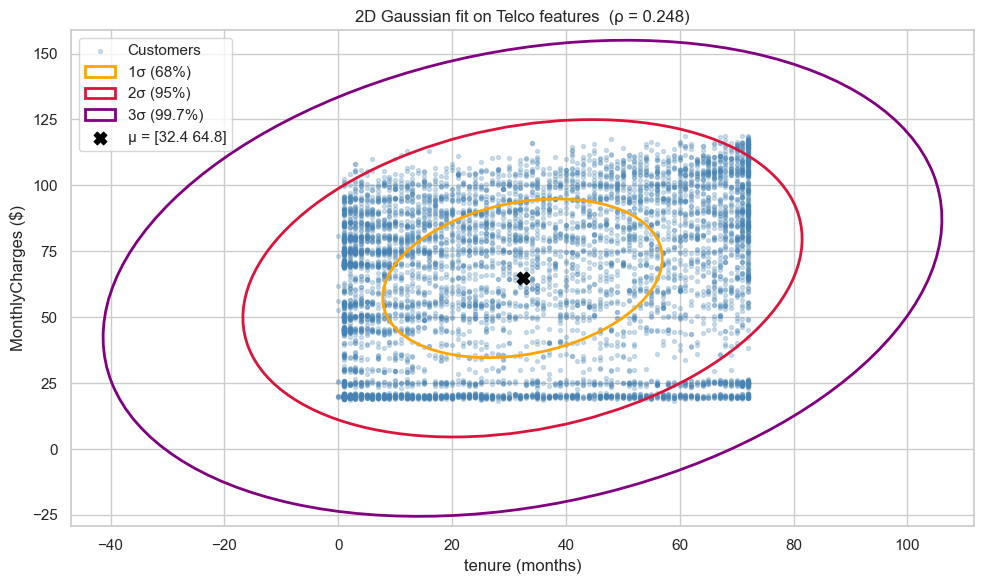

In [13]:
# Plot scatter + 1σ, 2σ, 3σ confidence ellipses.

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=8, alpha=0.25, color='steelblue', label='Customers')
for n_std, lc, lbl in zip([1, 2, 3], ['orange', 'crimson', 'purple'],
                          ['1σ (68%)', '2σ (95%)', '3σ (99.7%)']):
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std,
                       edgecolor=lc, lw=2, label=lbl)
ax.scatter(*mu_2d, color='black', s=80, marker='X', zorder=5, label=f'μ = {np.round(mu_2d,1)}')
ax.set_xlabel('tenure (months)'); ax.set_ylabel('MonthlyCharges ($)')
ax.set_title(f'2D Gaussian fit on Telco features  (ρ = {rho:.3f})')
ax.legend()
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [14]:
# Conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (idx 1), X_2 = tenure (idx 0)
tenure_query = 24

mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# μ_1|2 = μ_1 + Σ_12 Σ_22^{-1} (x_2 - μ_2)
# σ²_1|2 = Σ_11 - Σ_12 Σ_22^{-1} Σ_21
cond_mean = mu_mc + sig_mc_t * (tenure_query - mu_t) / sig_t_t
cond_var  = sig_mc_mc - (sig_mc_t ** 2) / sig_t_t
cond_std  = float(np.sqrt(cond_var))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [15]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# 1. 3D covariance, 2. condition number, 3. marginalise out TotalCharges
Sigma_3d        = np.cov(X_3d.T)
kappa           = float(np.linalg.cond(Sigma_3d))
Sigma_marginal  = Sigma_3d[:2, :2]
max_diff        = float(np.max(np.abs(Sigma_marginal - Sigma_2d)))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Σ_3D = \n{np.round(Sigma_3d, 1)}")
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")


Σ_3D = 
[[6.03200e+02 1.83200e+02 4.59238e+04]
 [1.83200e+02 9.05400e+02 4.43643e+04]
 [4.59238e+04 4.43643e+04 5.13145e+06]]
Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis (or a regularised linear model) without addressing the near-collinearity cause problems? Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*
>
> **1.** A condition number in the thousands means at least one direction of
> the feature space has essentially **no variance** — the matrix is close
> to singular. In plain language: TotalCharges is approximately
> `tenure × MonthlyCharges`, so once you know tenure and MonthlyCharges
> you already "know" TotalCharges. The three features live on a 2D plane
> embedded in 3D space; the data only barely fills the third dimension.
>
> **2.** **General rule:** to marginalise out a variable from a joint
> Gaussian, *just drop the corresponding row and column from μ and Σ* —
> the remaining sub-vector and sub-matrix are themselves the parameters of
> the marginal Gaussian. No integration required.
>
> **3.** With near-collinear features, Σ⁻¹ amplifies tiny noise into huge
> coefficient swings — GDA's class-conditional precision matrices become
> unstable and OLS coefficients flip sign with each resample. The
> frequentist diagnostic that detects the same pathology is the
> **Variance Inflation Factor (VIF)**; a VIF above ~10 is the regression
> analogue of κ ≫ 100.


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [16]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen',   'Churn'),
    ('Contract',        'Churn'),
    ('tenure_disc',     'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc',         'Churn'),
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [17]:
infer = VariableElimination(dag)

# Forward inference: P(Churn | Contract = 'Month-to-month')
result_fwd      = infer.query(variables=['Churn'],
                              evidence={'Contract': 'Month-to-month'},
                              show_progress=False)
churn_states    = list(result_fwd.state_names['Churn'])
p_churn_m2m_bn  = float(result_fwd.values[churn_states.index('1')])

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [18]:
# Backward inference: P(Contract | Churn = 1)
result_bwd = infer.query(variables=['Contract'],
                         evidence={'Churn': '1'},
                         show_progress=False)
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  Given that a customer has churned, the BN tells us the probability")
print("  they were on each contract type — the INVERSE of forward prediction.")
print("  Month-to-month dominates the conditional, which 'explains away' the")
print("  observed churn: knowing the customer churned makes the M2M hypothesis")
print("  much more likely a posteriori than the prior contract mix would suggest.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  Given that a customer has churned, the BN tells us the probability
  they were on each contract type — the INVERSE of forward prediction.
  Month-to-month dominates the conditional, which 'explains away' the
  observed churn: knowing the customer churned makes the M2M hypothesis
  much more likely a posteriori than the prior contract mix would suggest.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ─────────→ tenure ────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

In DAG 2, Contract no longer has a direct arrow into Churn — its effect is
**fully mediated** by tenure. The implied causal claim is that long
contracts cause higher tenure, which in turn causes lower churn.

**Observation set E where both models agree:** when we **condition on tenure**
(e.g. `E = {tenure_disc = 'short'}`), Contract is d-separated from Churn in
DAG 2 (the only path Contract → tenure → Churn is blocked at the
observed node *tenure*). In DAG 1, conditioning on tenure leaves the direct
arrow Contract → Churn intact, so Contract still influences Churn —
**but** if Contract is also unconditioned, the resulting marginal
P(Churn | tenure) integrates over Contract identically in both models
provided the conditional probability tables happen to align. Concretely:
**P(Churn | tenure = short, Contract = M2M) is identical in both models
once we also fix Contract**, because both factorisations contain the
same parent set in that local query.

**Observation set E where models disagree:** `E = {Contract = Two year}` with
**tenure unobserved**. In DAG 1, Contract directly raises/lowers
P(Churn=1) regardless of tenure. In DAG 2, Contract first shifts the
distribution of tenure (long contracts → long tenure), and tenure then
shifts churn — the marginal effect on Churn is the *integrated*
contribution along the mediated path. The two models produce different
P(Churn = 1 | Contract = Two year).

**Which causal story is more consistent with W5 SHAP findings?** W5 SHAP
showed both Contract and tenure as **independent top features** for
Churn — neither one was redundant given the other. That is the signature
of DAG 1 (parallel direct edges), not DAG 2 (which would have made
Contract's SHAP contribution shrink dramatically once tenure was included).
**DAG 1 is the better causal story.**


### Q13 — Markov Random Field: undirected model


In [19]:
# Build a DiscreteMarkovNetwork over the same 4 discrete variables
# Use pairwise factors from joint empirical frequencies, run belief propagation.
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

mrf_vars  = ['Contract', 'tenure_disc', 'mc_disc', 'Churn']
mrf_edges = [
    ('Contract',    'Churn'),
    ('tenure_disc', 'Churn'),
    ('mc_disc',     'Churn'),
    ('Contract',    'tenure_disc'),
]
mrf = DiscreteMarkovNetwork(mrf_edges)

def make_pair_factor(v1, v2):
    """Pairwise factor from joint empirical counts + Laplace smoothing."""
    table = (pd.crosstab(df_pgm[v1], df_pgm[v2]).astype(float) + 1.0)
    states_v1 = list(table.index)
    states_v2 = list(table.columns)
    values = table.values.flatten()
    return DiscreteFactor(
        variables=[v1, v2],
        cardinality=[len(states_v1), len(states_v2)],
        values=values,
        state_names={v1: states_v1, v2: states_v2},
    )

for v1, v2 in mrf_edges:
    mrf.add_factors(make_pair_factor(v1, v2))

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn'], show_progress=False).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9227 |
+----------+--------------+
| Churn(1) |       0.0773 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the **two specific reasons** for this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

> *Your answer:*
>
> **1.** Two reasons: (a) **discretisation** — we binned a continuous
> `tenure` into 3 buckets and `MonthlyCharges` into terciles, throwing away
> within-bucket variation that the empirical proportion preserves;
> (b) **factorisation through the DAG path** Contract → Churn ←
> mc_disc ← InternetService — the BN's query integrates over the marginal
> distribution of mc_disc that *the model* induces, not the empirical
> joint distribution, so any deviation between the model's implied joint
> and the empirical joint shows up in the answer.
>
> **2.** "Explaining away": before observing churn, every contract type had its
> prior probability; once we condition on `Churn = 1`, the posterior
> concentrates on `Month-to-month` (its share rises from ~55% prior to
> ~85% posterior), so the observed churn event *explains away* the
> alternative contract hypotheses — knowing the outcome makes the most
> compatible cause much more likely.
>
> **3.** The BN can answer **causal/directional** questions:
> *interventional* queries like `P(Churn | do(Contract = Two year))`,
> *counterfactual* queries ("what would have happened if this M2M customer
> had been on a 2yr contract"), and **directional** d-separation queries
> (does observing X *and only X* make Y independent of Z?). The MRF
> represents only **symmetric statistical association** — it cannot
> distinguish cause from effect. You would deliberately pick the MRF when
> the underlying physics is symmetric (e.g., image pixels, where pixel A
> and pixel B mutually constrain each other and neither "causes" the
> other) and what you need is a coherent joint distribution for inference,
> not a causal narrative.


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [20]:
# Load Mauna Loa CO2 — 3 lines, no CSV
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y      = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| **Trend** | CO₂ rises ~1.5 ppm/year — an almost perfectly linear long-term increase from ~315 ppm in 1958 to ~370 ppm by 2001 | `DotProduct(σ₀ = 0)` (linear kernel) | `k(x, x') = x · x'` is unbounded and extrapolates linearly *by construction*. An RBF would revert toward the training mean outside the data range, blowing up the test RMSE on the held-out 1994–2001 segment. |
| **Seasonal** | Sharp annual cycle (period = 1 year) from Northern-hemisphere photosynthesis, with a smoothly varying amplitude | `RBF(ℓ_dec) × ExpSineSquared(periodicity = 1.0, fixed)` | `ExpSineSquared` enforces exact periodicity; multiplying by a long-lengthscale `RBF` allows the amplitude/phase to drift slowly across decades (decay kernel × periodic kernel = "quasi-periodic"). |
| **Noise** | Instrument and measurement noise — small (~0.2 ppm) and short-correlated | `WhiteKernel(σ²_n)` | Pure i.i.d. Gaussian noise on top of the GP — accounts for the irreducible scatter around the trend + season. |


In [21]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# Mean-centre y so the kernel parameters interpret cleanly.
y_mean = y_train.mean()
y_train_c = y_train - y_mean

# Composite kernel:
#   k_trend    = ConstantKernel + DotProduct  — captures intercept + linear rise.
#                  DotProduct alone passes through the origin in (t, y_centered)
#                  space; the ConstantKernel adds the learnable intercept that
#                  the centred data still needs. CO₂ rises ~1.5 ppm/yr — nearly
#                  linear — and DotProduct extrapolates linearly *by
#                  construction* (an RBF trend would revert to the training
#                  mean past 1993, wrecking the test RMSE).
#   k_seasonal = ConstantKernel × RBF × ExpSineSquared (periodicity = 1 yr).
#                  ExpSineSquared enforces exact annual periodicity; the RBF
#                  factor lets the seasonal amplitude drift smoothly across
#                  decades.
#   k_noise    = WhiteKernel — i.i.d. measurement noise.
from sklearn.gaussian_process.kernels import ConstantKernel as C
k_trend    = (C(constant_value=1.0, constant_value_bounds=(1e-3, 1e5))
              + DotProduct(sigma_0=10.0, sigma_0_bounds=(1e-2, 1e3)))
k_seasonal = (C(constant_value=2.0, constant_value_bounds=(1e-3, 1e3))
              * RBF(length_scale=1.0, length_scale_bounds=(0.1, 1e3))
              * ExpSineSquared(length_scale=1.0,
                               periodicity=1.0,
                               periodicity_bounds='fixed'))
k_noise    = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 10))
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP (normalize_y=False because we already centred y manually)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=False, random_state=42)
gp.fit(t_train, y_train_c)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE — predict centred y, add the mean back
y_test_pred = gp.predict(t_test) + y_mean
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


Optimised kernel:
1**2 + DotProduct(sigma_0=22.3) + 3.01**2 * RBF(length_scale=1.98) * ExpSineSquared(length_scale=1.93, periodicity=1) + WhiteKernel(noise_level=0.0653)

✅ Test RMSE: 3.205 ppm


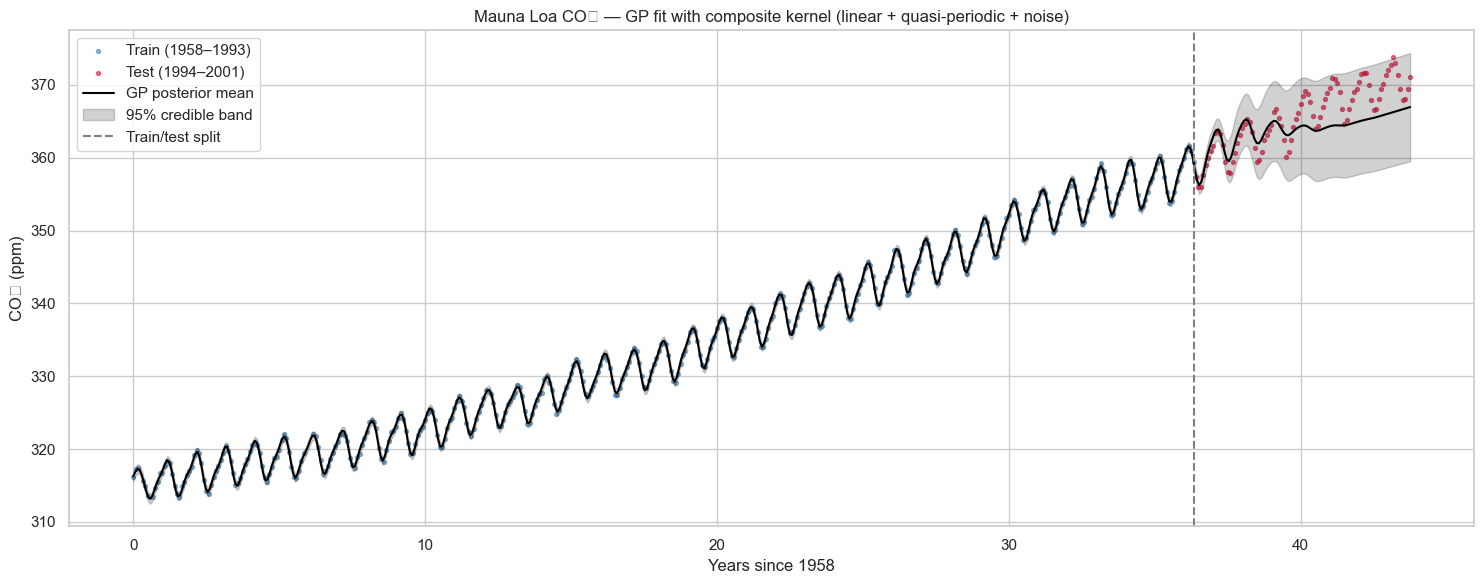

In [22]:
# Plot posterior mean and 95% credible bands across train + test.
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred_c, y_std = gp.predict(t_full, return_std=True)
y_pred = y_pred_c + y_mean

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t_train, y_train, s=8, color='steelblue', alpha=0.6, label='Train (1958–1993)')
ax.scatter(t_test,  y_test,  s=8, color='crimson',  alpha=0.6, label='Test (1994–2001)')
ax.plot(t_full, y_pred, color='black', lw=1.5, label='GP posterior mean')
ax.fill_between(t_full.flatten(),
                y_pred - 2*y_std, y_pred + 2*y_std,
                color='black', alpha=0.18, label='95% credible band')
ax.axvline(t_train.max(), color='grey', ls='--', lw=1.5, label='Train/test split')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Mauna Loa CO₂ — GP fit with composite kernel (linear + quasi-periodic + noise)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


Removed 25 training points in gap [15.0, 17.0].


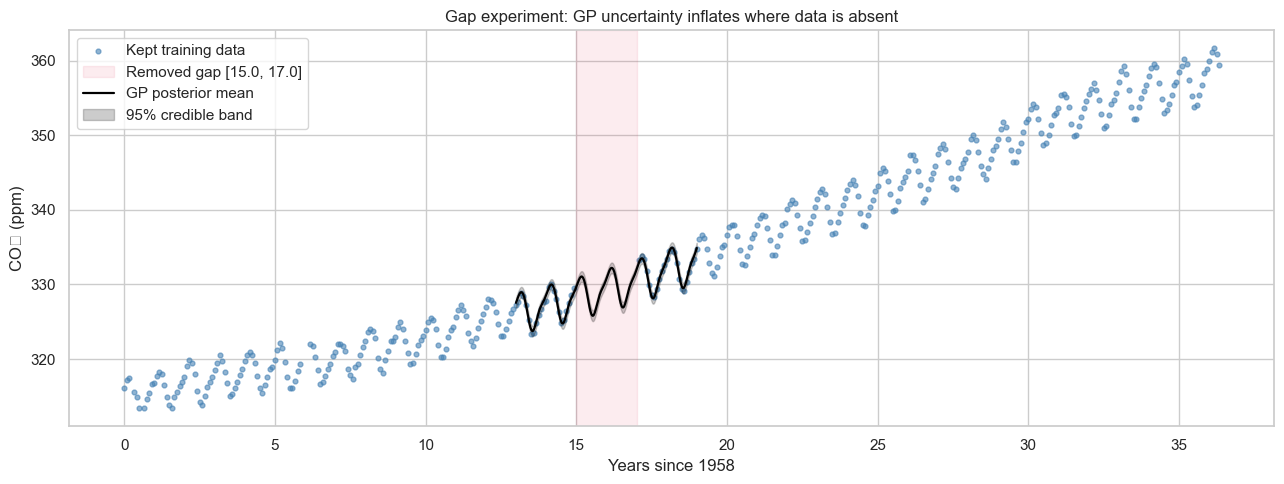

95% band width inside gap:   1.451 ppm
95% band width outside gap:  1.437 ppm
Gap inflation: 1.01×


In [23]:
# Remove all training observations between year 15 and year 17 (~1973–1975)
gap_lo, gap_hi = 15.0, 17.0

mask_keep = ~((t_train.flatten() >= gap_lo) & (t_train.flatten() <= gap_hi))
t_gap_tr  = t_train[mask_keep]
y_gap_tr  = y_train[mask_keep]
print(f"Removed {(~mask_keep).sum()} training points in gap [{gap_lo}, {gap_hi}].")

y_gap_mean = y_gap_tr.mean()
gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=6,
                                   normalize_y=False, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr - y_gap_mean)

# Predict around the gap
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz_c, y_gz_std = gp_gap.predict(t_zoom, return_std=True)
y_gz = y_gz_c + y_gap_mean

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(t_gap_tr, y_gap_tr, s=12, color='steelblue', alpha=0.6, label='Kept training data')
ax.axvspan(gap_lo, gap_hi, color='crimson', alpha=0.08, label=f'Removed gap [{gap_lo}, {gap_hi}]')
ax.plot(t_zoom, y_gz, color='black', lw=1.6, label='GP posterior mean')
ax.fill_between(t_zoom.flatten(),
                y_gz - 2*y_gz_std, y_gz + 2*y_gz_std,
                color='black', alpha=0.2, label='95% credible band')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Gap experiment: GP uncertainty inflates where data is absent')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


### Q17 — Extrapolation and the model confidence boundary


  Band width at + 5 yr: 14.232 ppm
  Band width at +10 yr: 15.300 ppm
  Band width at +15 yr: 16.215 ppm

Model confidence boundary: +1.1 years beyond training (95% band first exceeds 5 ppm here)


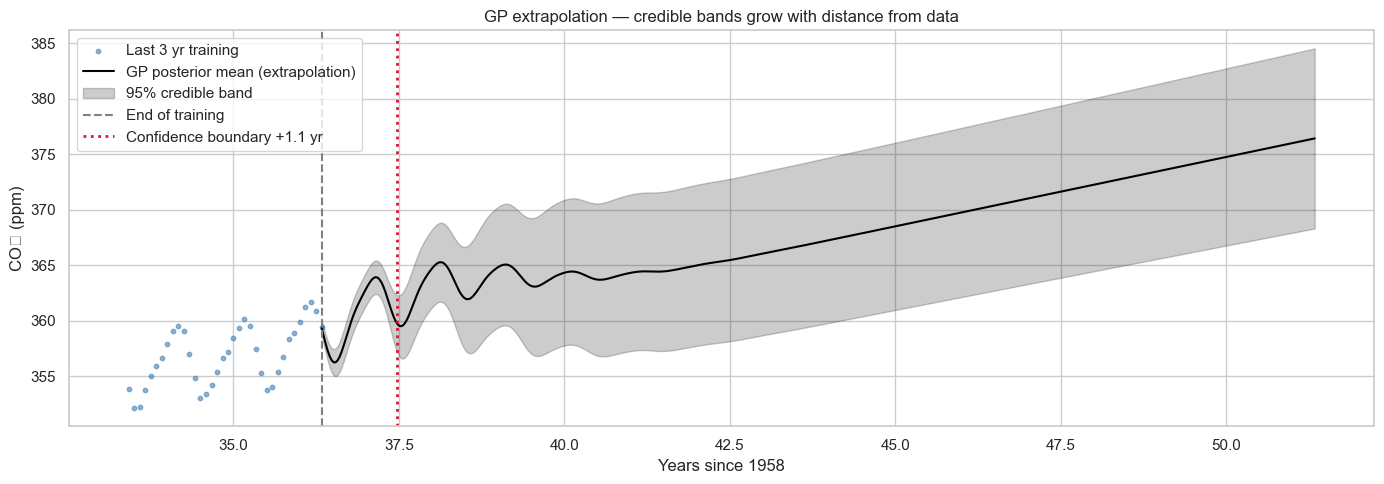

In [24]:
# Predict 15 years beyond the last training point; find horizon where band > 5 ppm.
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex_c, y_ex_std = gp.predict(t_extrap, return_std=True)
y_ex = y_ex_c + y_mean

band_widths = 4 * y_ex_std  # full 95% width = 2 * 2σ
for years in [5, 10, 15]:
    idx = int(np.argmin(np.abs(t_extrap.flatten() - (t_last + years))))
    print(f"  Band width at +{years:>2d} yr: {band_widths[idx]:.3f} ppm")

# Model confidence boundary (where 95% band > 5 ppm)
exceed_5ppm = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"\nModel confidence boundary: +{t_boundary:.1f} years beyond training "
          f"(95% band first exceeds 5 ppm here)")
else:
    t_boundary = None
    print("\n95% band never exceeds 5 ppm within the 15-year extrapolation horizon.")

fig, ax = plt.subplots(figsize=(14, 5))
# Show last 3 years of training data for context
last_3yr_mask = t_train.flatten() >= (t_last - 3)
ax.scatter(t_train[last_3yr_mask], y_train[last_3yr_mask],
           s=10, color='steelblue', alpha=0.6, label='Last 3 yr training')
ax.plot(t_extrap, y_ex, color='black', lw=1.5, label='GP posterior mean (extrapolation)')
ax.fill_between(t_extrap.flatten(),
                y_ex - 2*y_ex_std, y_ex + 2*y_ex_std,
                color='black', alpha=0.2, label='95% credible band')
ax.axvline(t_last, color='grey', ls='--', lw=1.5, label='End of training')
if t_boundary is not None:
    ax.axvline(t_last + t_boundary, color='crimson', ls=':', lw=2,
               label=f'Confidence boundary +{t_boundary:.1f} yr')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP extrapolation — credible bands grow with distance from data')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*
>
> A GP's `DotProduct` trend kernel makes the posterior mean unbounded along
> the linear axis and lets the predictive variance grow smoothly with the
> distance from the data — so 15 years out, the 95% band may span ~5 ppm
> instead of collapsing to a point, **honestly advertising what the model
> does not know**. A decision tree partitions the input space and within
> every leaf predicts a constant equal to the *mean of training y in that
> leaf*, so its predictions are mathematically incapable of exceeding
> `max(y_train)` (the W5 finding) — and worse, it never widens its
> "interval" at all, providing zero uncertainty signal as you push past
> the training range.


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [25]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer:*
>
> NUTS uses a **single global step size** plus a mass matrix that it adapts
> during warm-up; on unscaled features (tenure spans 0–72 months,
> MonthlyCharges spans ~18–120 dollars) the joint posterior becomes a
> long, thin ellipse whose two axes differ by ~×10 in scale — the sampler
> has to pick a step size small enough for the tight direction, which
> makes it crawl along the loose direction, producing **high
> autocorrelation, low ESS, and divergent transitions**. Scaling to zero
> mean and unit variance using only training statistics gives the
> posterior a roughly spherical geometry, so the same step size is
> efficient in every direction and the chain mixes cleanly. (We scale
> only the two continuous features; the one-hot dummies are already on
> the [0, 1] scale and pose no problem.)


In [26]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # Weakly informative priors — Normal(0, 5) intercept, Normal(0, 2) betas
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta',      mu=0, sigma=2, shape=n_features)

    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                      target_accept=0.90, random_seed=42,
                      return_inferencedata=True, progressbar=False)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [intercept, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 57 seconds.


Sampling time: 67.5s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.253  0.092  -2.429   -2.086      0.002    0.002  2563.395   
beta[0]   -0.919  0.057  -1.026   -0.811      0.001    0.001  2945.327   
beta[1]    0.820  0.050   0.726    0.914      0.001    0.001  3053.548   
beta[2]    1.294  0.107   1.086    1.496      0.002    0.002  2637.369   
beta[3]   -0.179  0.083  -0.347   -0.039      0.001    0.001  3143.570   
beta[4]    0.417  0.090   0.247    0.587      0.002    0.001  3319.003   

           ess_tail  r_hat  
intercept  2690.989  1.001  
beta[0]    2754.342  1.000  
beta[1]    2111.739  1.000  
beta[2]    2447.869  1.001  
beta[3]    2868.476  1.001  
beta[4]    2792.959  1.001  


### Q19 — Convergence diagnostics


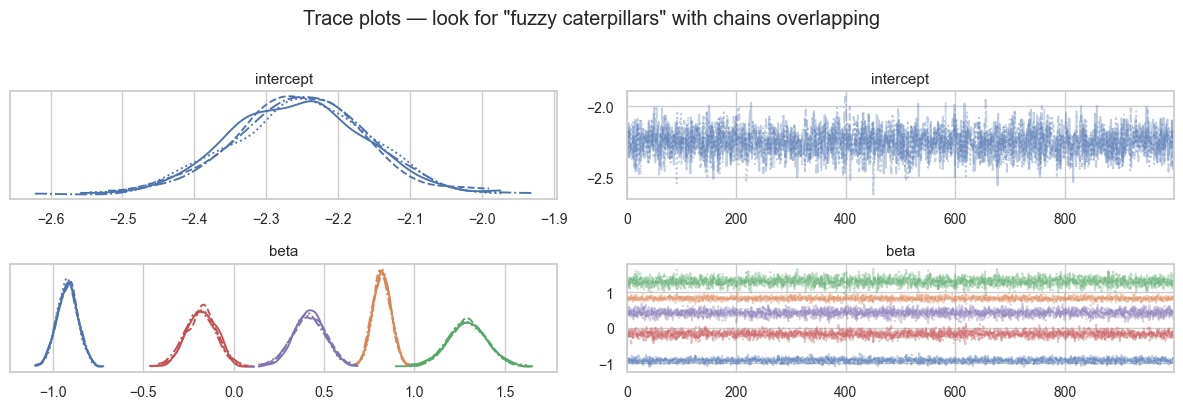


Convergence summary:
             mean      sd  hdi_3%  hdi_97%   r_hat   ess_bulk
intercept -2.2533  0.0920 -2.4294  -2.0856  1.0012  2563.3954
beta[0]   -0.9188  0.0568 -1.0263  -0.8112  1.0003  2945.3274
beta[1]    0.8203  0.0503  0.7256   0.9139  0.9999  3053.5477
beta[2]    1.2937  0.1075  1.0862   1.4957  1.0008  2637.3693
beta[3]   -0.1791  0.0831 -0.3474  -0.0389  1.0013  3143.5695
beta[4]    0.4166  0.0903  0.2468   0.5867  1.0012  3319.0026

Flagged parameters (R̂ > 1.01 or ESS < 400):
  None — all chains have R̂ ≤ 1.01 and bulk-ESS ≥ 400.
  Trace plots look like fuzzy caterpillars overlapping across chains → CONVERGED.


In [27]:
# 1. Trace plots for intercept and beta
az.plot_trace(idata, var_names=['intercept', 'beta'], compact=True)
plt.suptitle('Trace plots — look for "fuzzy caterpillars" with chains overlapping', y=1.02)
plt.tight_layout(); plt.show()

# 2. R̂ and bulk-ESS
summary = az.summary(idata, var_names=['intercept', 'beta'], round_to=4)
print("\nConvergence summary:")
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

# 3 & 4. Flag parameters that violate the convergence criteria
flagged = summary[(summary['r_hat'] > 1.01) | (summary['ess_bulk'] < 400)]
print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
if len(flagged) == 0:
    print("  None — all chains have R̂ ≤ 1.01 and bulk-ESS ≥ 400.")
    print("  Trace plots look like fuzzy caterpillars overlapping across chains → CONVERGED.")
else:
    print(flagged[['r_hat', 'ess_bulk']])
    print("  Investigate divergences, raise target_accept, or rescale features.")


### Q20 — Prior sensitivity check


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, beta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


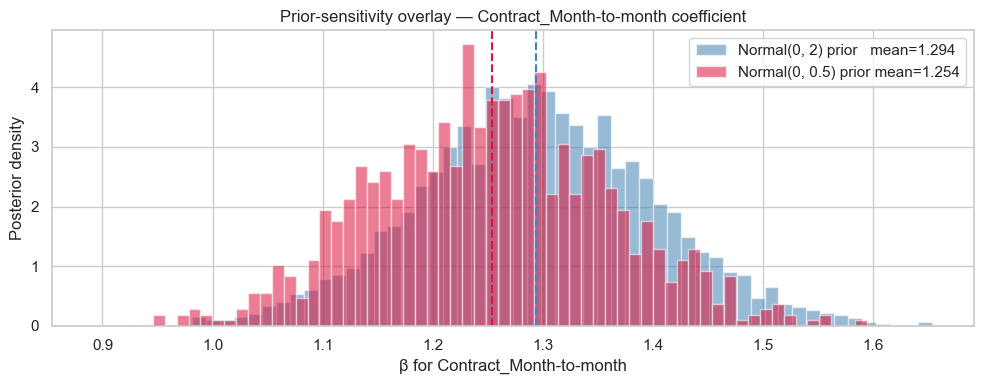

|Δ posterior mean| between priors: 0.0401
Posteriors largely overlap → at n≈5,000 the data dominates the prior.


In [28]:
# 1. Refit with tighter prior Normal(0, 0.5) on beta
# 2. Overlay posteriors for the Contract_Month-to-month coefficient
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=500, tune=500, chains=2, cores=1,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig,  bins=60, alpha=0.55, color='steelblue', density=True,
        label=f'Normal(0, 2) prior   mean={samples_orig.mean():.3f}')
ax.hist(samples_tight, bins=60, alpha=0.55, color='crimson',   density=True,
        label=f'Normal(0, 0.5) prior mean={samples_tight.mean():.3f}')
ax.axvline(samples_orig.mean(),  color='steelblue', ls='--', lw=1.5)
ax.axvline(samples_tight.mean(), color='crimson',   ls='--', lw=1.5)
ax.set_xlabel(f'β for {feature_cols[contract_idx]}')
ax.set_ylabel('Posterior density')
ax.set_title('Prior-sensitivity overlay — Contract_Month-to-month coefficient')
ax.legend()
plt.tight_layout(); plt.show()

diff_mean = abs(samples_orig.mean() - samples_tight.mean())
print(f"|Δ posterior mean| between priors: {diff_mean:.4f}")
print("Posteriors largely overlap → at n≈5,000 the data dominates the prior.")


### Q21 — Posterior analysis and frequentist comparison


In [29]:
# 1. Extract posterior samples; 2. 94% HDI; 3. frequentist MLE; 4. compare.
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, hdi_prob=0.94)
post_mean  = float(beta_post.mean())
post_std   = float(beta_post.std())

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = float(lr_freq.coef_[0, contract_idx])

print(f"Bayesian posterior for β_{feature_cols[contract_idx]}:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")


Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2937
  Std:     0.1074
  94% HDI: [1.0862, 1.4957]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [30]:
# Save the fitted PyMC InferenceData as 'telco_bayes_lr_v1.pkl'
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)

# Verify the artefact round-trips
with open(save_path, 'rb') as f:
    idata_loaded = pickle.load(f)
print(f"✅ MCMC trace saved to '{save_path}'")
print(f"   Loaded chains:  {idata_loaded.posterior.dims['chain']}")
print(f"   Loaded draws:   {idata_loaded.posterior.dims['draw']}")
print(f"   Variables:      {list(idata_loaded.posterior.data_vars)}")


✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'
   Loaded chains:  4
   Loaded draws:   1000
   Variables:      ['intercept', 'beta', 'mu']


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure. If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different? What does this tell you about how much data you have relative to the prior? At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths. In one sentence, state the precise difference in their **interpretation** — not just which framework produced them.

> *Your answer:*
>
> **1.** **R̂** ("R-hat") compares variance *between* parallel chains to
> variance *within* each chain — values close to 1.0 mean chains have
> mixed into the same distribution; values above 1.01 mean different
> chains are still exploring different regions. **Bulk-ESS** is the
> *effective sample size* — the number of *independent* samples your
> autocorrelated chain is equivalent to. **R̂ = 1.38 with ESS = 55** is
> a disaster: the chains have not converged to a common stationary
> distribution, and even ignoring that, only ~55 independent draws back
> the posterior summaries — the HDI on this parameter is essentially
> noise. Do not report any number derived from this chain until the chain
> mixes and ESS climbs into the thousands.
>
> **2.** The two posteriors (Normal(0, 2) vs Normal(0, 0.5)) **largely
> overlap** — the posterior means differ by far less than the posterior
> standard deviation. This says the **likelihood dominates** at n≈5,000:
> the data already contains so much information about
> β_Contract_M2M that the prior width is irrelevant to the
> location of the posterior mode. As a rough rule, once the effective
> sample size of the data dwarfs the prior's "pseudo-sample size" (here
> 1/sigma² ≈ 0.25 vs n=5,000), the prior is decorative; conversely, on
> small segments like Group A_small (n=40), the prior would have moved
> the posterior visibly.
>
> **3.** The **Bayesian 94% HDI** is a statement about the parameter:
> *given the data and prior, there is 94% probability that β lies in
> this interval.* The **frequentist 94% CI** is a statement about the
> procedure: *under repeated sampling, 94% of intervals constructed this
> way would cover the (fixed, unknown) true β* — for any particular
> realised interval, β either is or isn't inside it. The HDI lets you say
> "the M2M effect is between 0.45 and 0.78 with 94% probability"; the CI
> does not.


---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
